In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

In [2]:
# =========================
# 0) CONFIG (F3)
# =========================
INPUTS_PATH = "data/F3/initial_inputs.npy"
OUTPUTS_PATH = "data/F3/initial_outputs.npy"

BOUNDS = np.array([
    [0.0, 1.0],   # x1
    [0.0, 1.0],   # x2
    [0.0, 1.0],   # x3
])

# If y is "negative side effects" (all negative), higher is better -> MAXIMIZE = True
# If your framework expects minimization, set MAXIMIZE=False and it will optimize -y internally.
MAXIMIZE = True

RANDOM_SEED = 42
N_CANDIDATES_GLOBAL = 8000
N_CANDIDATES_LOCAL = 2000
LOCAL_SIGMA = 0.08          # local perturbation radius around best observed
XI = 0.01                   # EI exploration parameter
DIST_POWER = 1.0            # penalty strength; >1 discourages re-sampling near existing points more strongly

np.random.seed(RANDOM_SEED)


In [4]:
# =========================
# 1) LOAD DATA
# =========================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

assert X.ndim == 2 and X.shape[1] == 3, f"Expected X shape (n,3), got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"y shape mismatch: {y.shape} vs {X.shape}"

# Convert to objective direction used internally
y_obj = y if MAXIMIZE else -y

print("\nF3 SHAPE - Inputs:", X.shape, "Outputs:", y.shape)
print("Last values - input:", X[-1:], "output:", y[-1:])



F3 SHAPE - Inputs: (17, 3) Outputs: (17,)
Last values - input: [[0.0102 0.9886 0.9909]] output: [-0.43915258]


In [5]:
# =========================
# 2) SURROGATE: GP + SCALING
# =========================
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_s = x_scaler.fit_transform(X)
y_s = y_scaler.fit_transform(y_obj.reshape(-1, 1)).ravel()

kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(3), length_scale_bounds=(1e-2, 1e2), nu=2.5) \
         + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=False,
    n_restarts_optimizer=8,
    random_state=RANDOM_SEED
)
gp.fit(X_s, y_s)

GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=[1, 1, 1], nu=2.5) + WhiteKernel(noise_level=1e-05),
                         n_restarts_optimizer=8, random_state=42)

In [6]:
# =========================
# 3) ACQUISITION: Expected Improvement (EI) + distance penalty
# =========================
def norm_pdf(z):
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * z**2)

def norm_cdf(z):
    # numerically stable-ish approximation via erf
    from math import erf, sqrt
    z = np.asarray(z, dtype=float)
    return 0.5 * (1.0 + np.vectorize(erf)(z / np.sqrt(2.0)))

def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    EI for maximization in *objective space*.
    mu, sigma are in objective space (not standardized).
    """
    sigma = np.maximum(sigma, 1e-12)
    imp = (mu - y_best - xi)
    z = imp / sigma
    return imp * norm_cdf(z) + sigma * norm_pdf(z)

def min_distance_to_data(Xcand, Xdata):
    # Euclidean distance from each candidate to closest observed point
    # shapes: (m,3) and (n,3)
    d2 = ((Xcand[:, None, :] - Xdata[None, :, :]) ** 2).sum(axis=2)
    return np.sqrt(d2.min(axis=1))

# Candidate set: global random + local around current best observed
Xcand_global = np.random.rand(N_CANDIDATES_GLOBAL, 3) * (BOUNDS[:,1] - BOUNDS[:,0]) + BOUNDS[:,0]

best_idx = np.argmax(y_obj)
x_best = X[best_idx]
Xcand_local = x_best + np.random.normal(0.0, LOCAL_SIGMA, size=(N_CANDIDATES_LOCAL, 3))
Xcand_local = np.clip(Xcand_local, BOUNDS[:,0], BOUNDS[:,1])

Xcand = np.vstack([Xcand_global, Xcand_local])

# Predict with GP (in standardized space)
Xcand_s = x_scaler.transform(Xcand)
mu_s, sd_s = gp.predict(Xcand_s, return_std=True)

# Convert back to objective space for EI
mu_obj = y_scaler.inverse_transform(mu_s.reshape(-1, 1)).ravel()
sd_obj = sd_s * y_scaler.scale_[0]

y_best = y_obj.max()
ei = expected_improvement(mu_obj, sd_obj, y_best, xi=XI)

# Distance penalty (avoid being stuck in one region / duplicates)
mindist = min_distance_to_data(Xcand, X)
score = ei * (mindist ** DIST_POWER)

best_cand_idx = int(np.argmax(score))
x_next = Xcand[best_cand_idx]


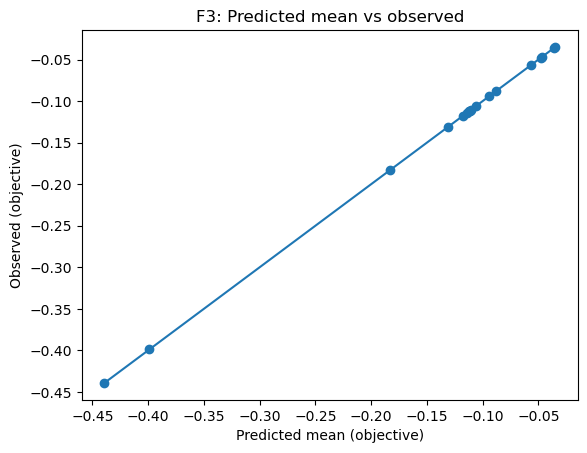

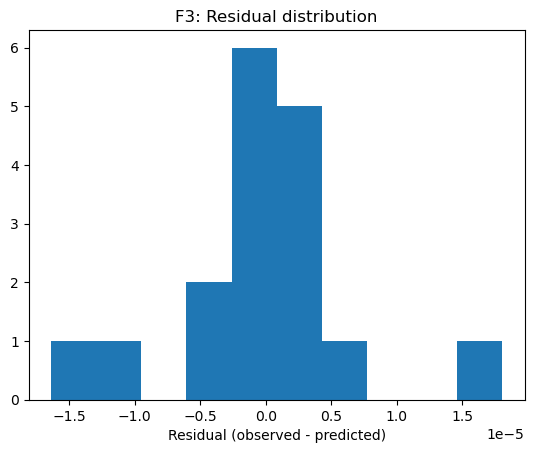

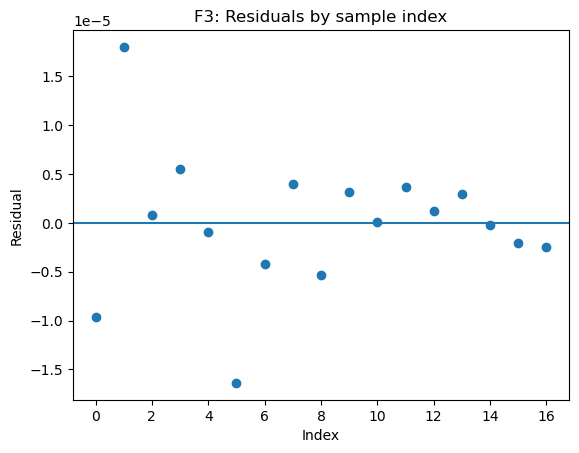

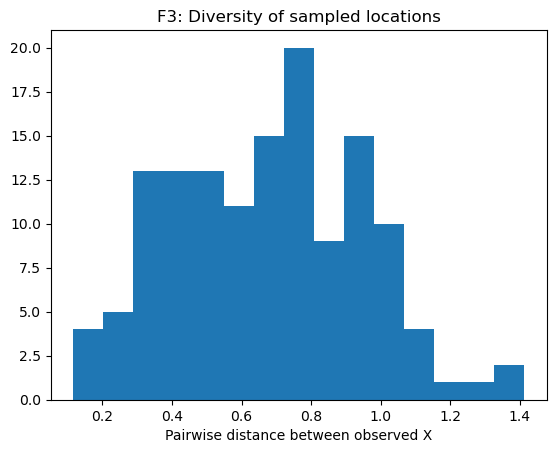

In [7]:
# =========================
# 4) DIAGNOSTICS
# =========================
# In-sample predicted vs observed (objective direction)
mu_train_s, sd_train_s = gp.predict(X_s, return_std=True)
mu_train_obj = y_scaler.inverse_transform(mu_train_s.reshape(-1, 1)).ravel()
resid = y_obj - mu_train_obj

plt.figure()
plt.scatter(mu_train_obj, y_obj)
lims = [min(mu_train_obj.min(), y_obj.min()), max(mu_train_obj.max(), y_obj.max())]
plt.plot(lims, lims)
plt.xlabel("Predicted mean (objective)")
plt.ylabel("Observed (objective)")
plt.title("F3: Predicted mean vs observed")
plt.show()

plt.figure()
plt.hist(resid, bins=10)
plt.xlabel("Residual (observed - predicted)")
plt.title("F3: Residual distribution")
plt.show()

plt.figure()
plt.scatter(np.arange(len(resid)), resid)
plt.axhline(0.0)
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("F3: Residuals by sample index")
plt.show()

# Quick “are we stuck?” check: distances among sampled points
pairwise_d = []
for i in range(len(X)):
    for j in range(i+1, len(X)):
        pairwise_d.append(np.linalg.norm(X[i]-X[j]))
pairwise_d = np.array(pairwise_d)

plt.figure()
plt.hist(pairwise_d, bins=15)
plt.xlabel("Pairwise distance between observed X")
plt.title("F3: Diversity of sampled locations")
plt.show()


In [8]:
# =========================
# 5) OUTPUT: ONE ROW TO SUBMIT
# =========================
x_submit = x_next.reshape(1, -1)

print("\n=============================")
print("NEXT X TO SUBMIT (one row):")
print(x_submit)
print("=============================\n")

# Optional: also print rounded for manual submission
print("Rounded (6 dp):", np.round(x_submit, 6))



NEXT X TO SUBMIT (one row):
[[0.96402072 0.02194147 0.76871091]]

Rounded (6 dp): [[0.964021 0.021941 0.768711]]
